# Monitoreo de Drift — Features del Dataset de Train

Este notebook simula un proceso de **monitoreo de drift** sobre el propio dataset de entrenamiento (`dataset/train.csv`), particionándolo semana a semana y comparando la distribución de cada feature de cada semana contra una semana de referencia (baseline).

Esto responde directamente a uno de los puntos planteados en `04_results/Resumen_Proyecto_Fraude.pdf` (slide "Consideraciones adicionales — Monitoreo del modelo en producción"): medir el drift del score y de las features de entrada es una buena práctica para detectar a tiempo si se verán afectadas las métricas del modelo y de negocio.

**Metodología:**
- Partición semanal (bins de 7 días desde la fecha mínima del dataset).
- **Semana de referencia**: semana 0 (baseline contra el que se comparan todas las semanas siguientes).
- **Variables continuas** (`b, c, d, e, f, h, l, m, monto, score`): estadístico **KS (Kolmogorov-Smirnov)** entre la semana de referencia y cada semana siguiente.
- **Variables categóricas** (`a, g, j, n, o, p`): **Population Stability Index (PSI)**, con nulos tratados como categoría propia.
- Se excluyen `k` (identificador único) y `fecha`. `fraude` se monitorea aparte, como referencia de contexto de negocio (no es una feature de entrada del modelo).

**Umbrales de alerta** (convención estándar de la industria):

| Métrica | Sin drift | Drift leve / moderado | Drift significativo |
|---|---|---|---|
| KS | < 0.10 | 0.10 – 0.20 | > 0.20 |
| PSI | < 0.10 | 0.10 – 0.25 | > 0.25 |


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT_DIR = Path.cwd().parent if (Path.cwd().name == "05_monitoring") else Path.cwd()
sys.path.insert(0, str(ROOT_DIR))

from src.monitoring_utils.drift_tests import (
    category_proportions,
    ks_drift,
    ks_drift_label,
    psi_categorical,
    psi_label,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATASET_DIR = ROOT_DIR / "dataset"
TRAIN_PATH = DATASET_DIR / "train.csv"

CONTINUOUS_FEATURES = ["b", "c", "d", "e", "f", "h", "l", "m", "monto", "score"]
CATEGORICAL_FEATURES = ["a", "g", "j", "n", "o", "p"]
TARGET_COL = "fraude"
DATE_COL = "fecha"

REFERENCE_WEEK = 0


## 1. Partición semanal del dataset

In [3]:
df = pd.read_csv(TRAIN_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

min_date = df[DATE_COL].min().normalize()
df["semana"] = ((df[DATE_COL].dt.normalize() - min_date).dt.days // 7).astype(int)

week_summary = df.groupby("semana").agg(
    n_transacciones=(TARGET_COL, "size"),
    tasa_fraude=(TARGET_COL, "mean"),
    fecha_inicio=(DATE_COL, "min"),
    fecha_fin=(DATE_COL, "max"),
).reset_index()
week_summary["fecha_inicio"] = week_summary["fecha_inicio"].dt.date
week_summary["fecha_fin"] = week_summary["fecha_fin"].dt.date
week_summary["tasa_fraude"] = (week_summary["tasa_fraude"] * 100).round(2)

n_weeks = df["semana"].nunique()
print(f"Dataset particionado en {n_weeks} semanas (semana de referencia = {REFERENCE_WEEK}).")
week_summary


Dataset particionado en 5 semanas (semana de referencia = 0).


,semana,n_transacciones,tasa_fraude,fecha_inicio,fecha_fin
0,0,24591,4.84,2020-03-08,2020-03-14
1,1,25140,4.52,2020-03-15,2020-03-21
2,2,20935,5.46,2020-03-22,2020-03-28
3,3,16800,5.95,2020-03-29,2020-04-04
4,4,17515,5.56,2020-04-05,2020-04-09


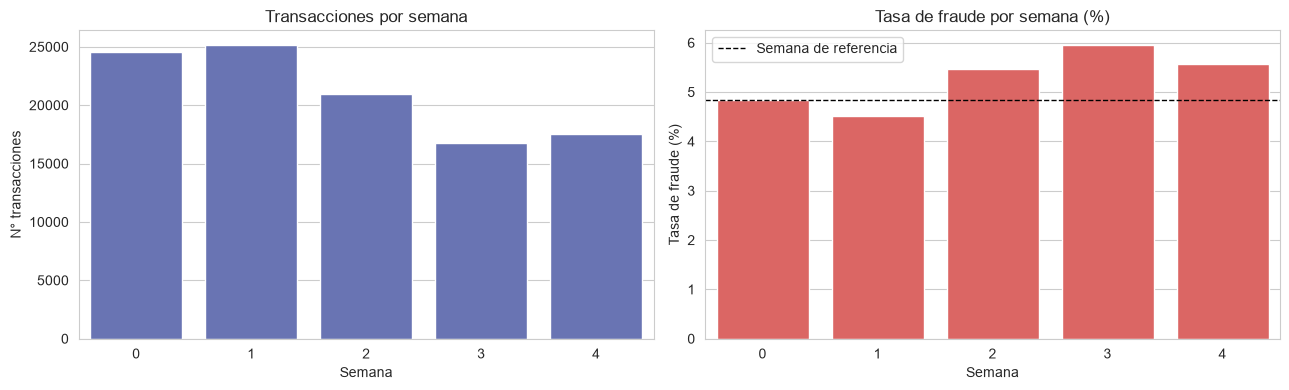

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=week_summary, x="semana", y="n_transacciones", color="#5c6bc0", ax=axes[0])
axes[0].set_title("Transacciones por semana")
axes[0].set_xlabel("Semana"); axes[0].set_ylabel("N° transacciones")

sns.barplot(data=week_summary, x="semana", y="tasa_fraude", color="#ef5350", ax=axes[1])
axes[1].set_title("Tasa de fraude por semana (%)")
axes[1].set_xlabel("Semana"); axes[1].set_ylabel("Tasa de fraude (%)")
axes[1].axhline(
    week_summary.loc[week_summary["semana"] == REFERENCE_WEEK, "tasa_fraude"].iloc[0],
    color="black", linestyle="--", linewidth=1, label="Semana de referencia",
)
axes[1].legend()

fig.tight_layout()
plt.show()


## 2. Variables continuas: drift vía KS (Kolmogorov-Smirnov)

In [5]:
reference_df = df.loc[df["semana"] == REFERENCE_WEEK]

ks_rows = []
for week in sorted(df["semana"].unique()):
    if week == REFERENCE_WEEK:
        continue
    current_df = df.loc[df["semana"] == week]
    for col in CONTINUOUS_FEATURES:
        stats_ = ks_drift(reference_df[col], current_df[col])
        ks_rows.append({"feature": col, "semana": week, **stats_})

ks_df = pd.DataFrame(ks_rows)
ks_pivot = ks_df.pivot(index="feature", columns="semana", values="ks_stat")
ks_pivot


semana,1,2,3,4
feature,,,,
b,0.011278,0.047260,0.104443,0.099108
c,0.012112,0.014589,0.014048,0.039076
d,0.014250,0.016557,0.028812,0.031701
e,0.008421,0.013342,0.057968,0.069719
f,0.007920,0.006346,0.029001,0.025781
h,0.037671,0.101115,0.110861,0.076733
l,0.009454,0.014170,0.008613,0.007406
m,0.012510,0.013462,0.026147,0.016117
monto,0.028397,0.046173,0.103835,0.102157


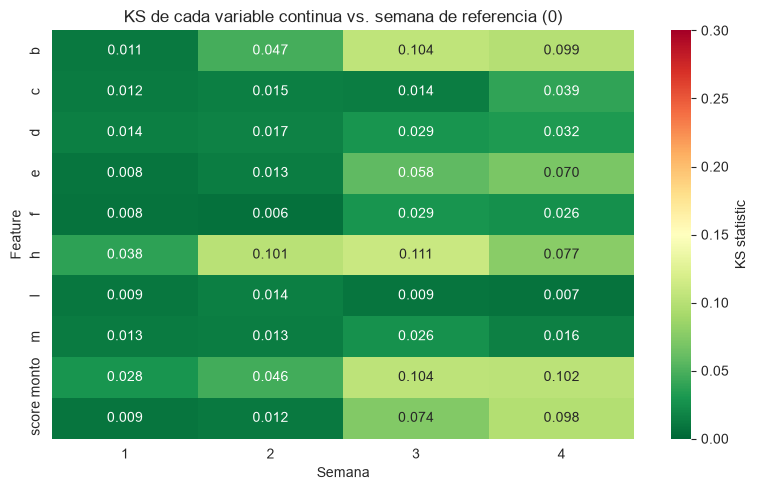

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    ks_pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=0.3,
    cbar_kws={"label": "KS statistic"}, ax=ax,
)
ax.set_title(f"KS de cada variable continua vs. semana de referencia ({REFERENCE_WEEK})")
ax.set_xlabel("Semana"); ax.set_ylabel("Feature")
fig.tight_layout()
plt.show()


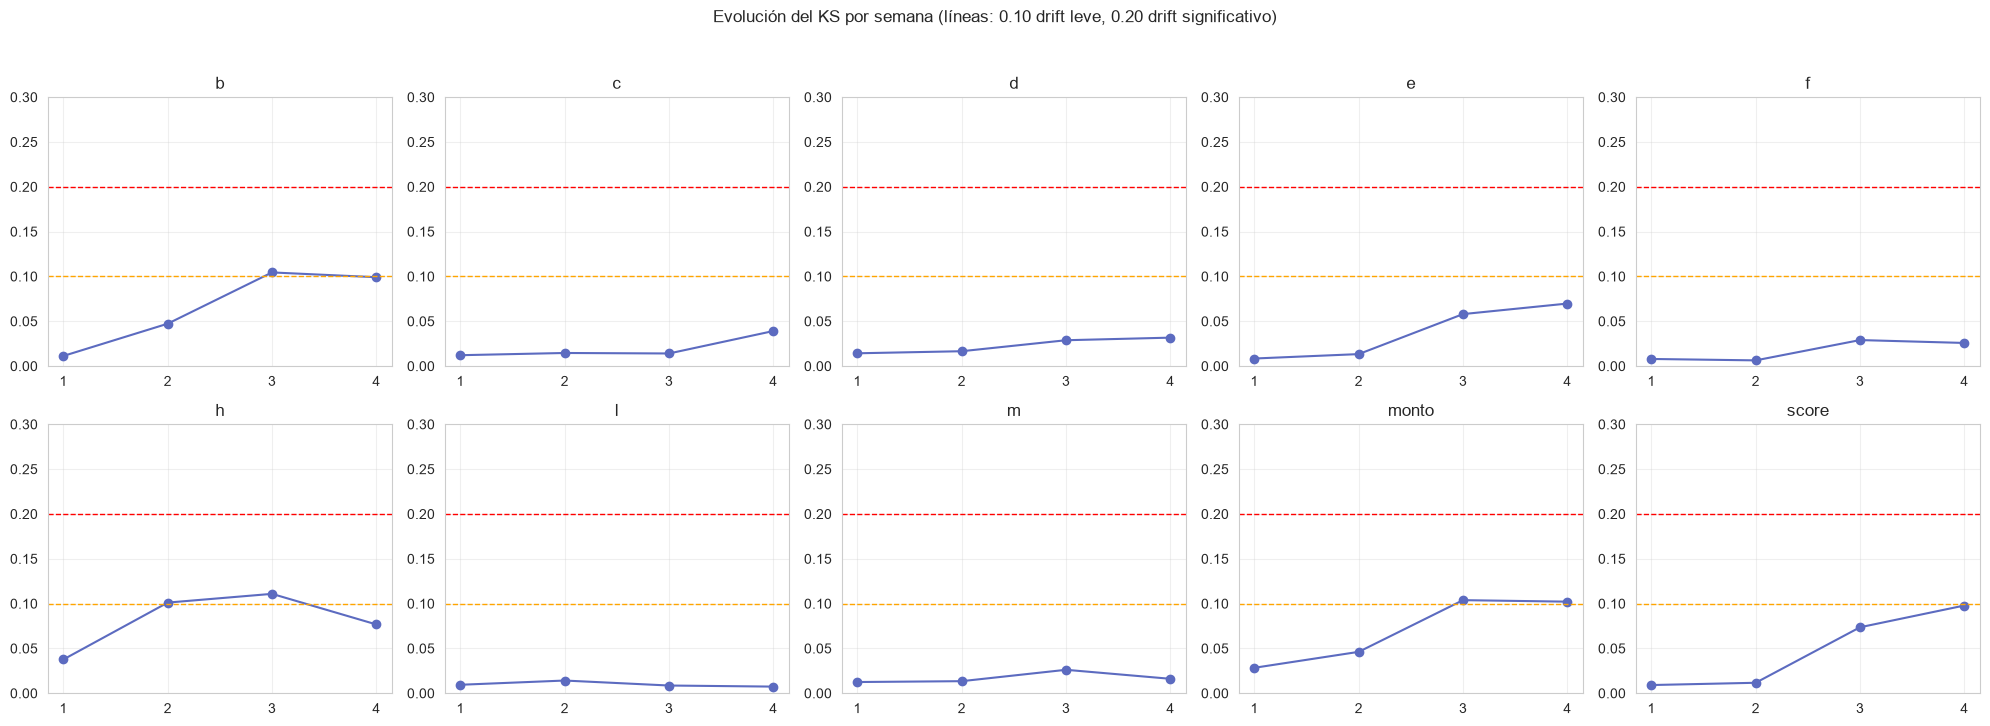

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
weeks_no_ref = sorted(w for w in df["semana"].unique() if w != REFERENCE_WEEK)

for i, col in enumerate(CONTINUOUS_FEATURES):
    vals = ks_pivot.loc[col, weeks_no_ref]
    axes[i].plot(weeks_no_ref, vals, marker="o", color="#5c6bc0")
    axes[i].axhline(0.1, color="orange", linestyle="--", linewidth=1)
    axes[i].axhline(0.2, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(col)
    axes[i].set_ylim(0, max(0.3, float(vals.max()) * 1.2))
    axes[i].set_xticks(weeks_no_ref)
    axes[i].grid(True, alpha=0.3)

fig.suptitle("Evolución del KS por semana (líneas: 0.10 drift leve, 0.20 drift significativo)", y=1.03)
fig.tight_layout()
plt.show()


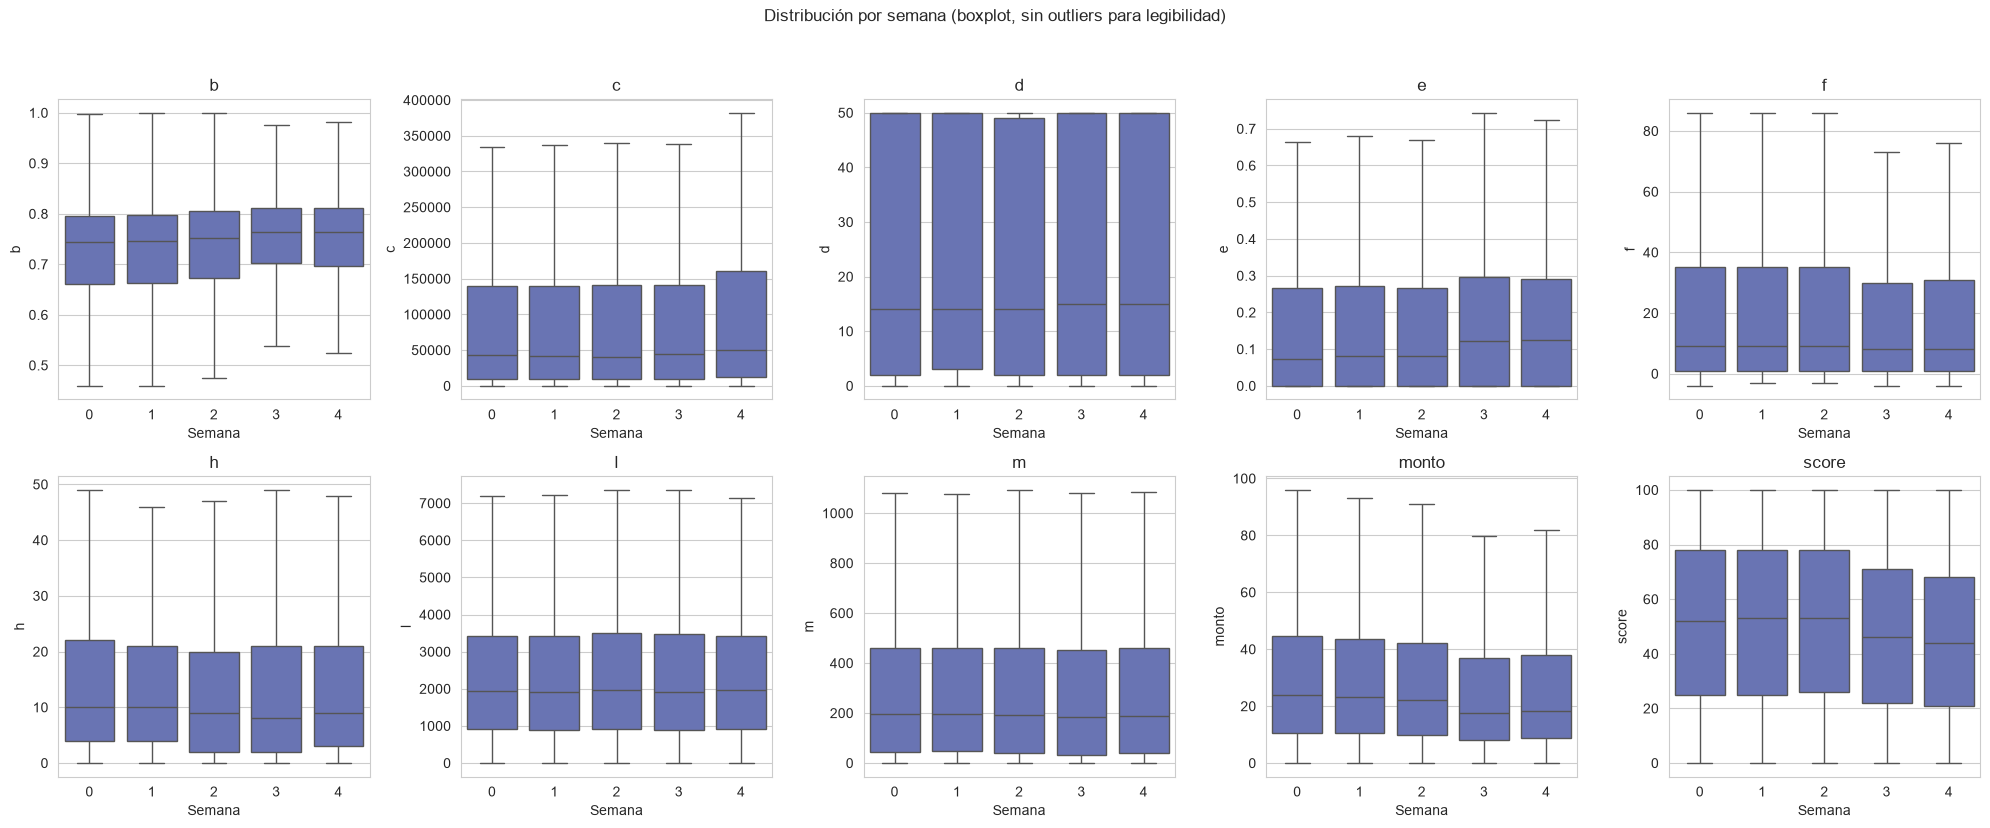

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(CONTINUOUS_FEATURES):
    sns.boxplot(data=df, x="semana", y=col, ax=axes[i], color="#5c6bc0", showfliers=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Semana")

fig.suptitle("Distribución por semana (boxplot, sin outliers para legibilidad)", y=1.03)
fig.tight_layout()
plt.show()


## 3. Variables categóricas: drift vía PSI

In [9]:
psi_rows = []
for week in sorted(df["semana"].unique()):
    if week == REFERENCE_WEEK:
        continue
    current_df = df.loc[df["semana"] == week]
    for col in CATEGORICAL_FEATURES:
        psi_val = psi_categorical(reference_df[col], current_df[col])
        psi_rows.append({"feature": col, "semana": week, "psi": psi_val})

psi_df = pd.DataFrame(psi_rows)
psi_pivot = psi_df.pivot(index="feature", columns="semana", values="psi")
psi_pivot


semana,1,2,3,4
feature,,,,
a,0.000344,0.001116,0.004202,0.021883
g,0.001461,0.006526,0.061179,0.025853
j,0.002011,0.008518,0.028585,0.022881
n,0.000476,0.000234,0.001081,0.000528
o,0.000073,0.000037,0.001480,0.000660
p,0.000098,0.000035,0.002534,0.000898


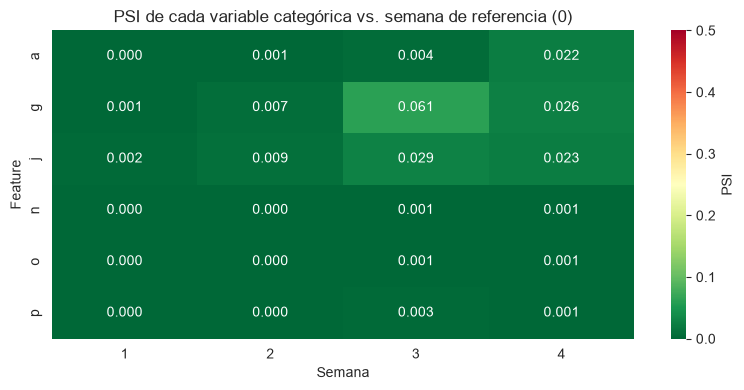

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    psi_pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=0.5,
    cbar_kws={"label": "PSI"}, ax=ax,
)
ax.set_title(f"PSI de cada variable categórica vs. semana de referencia ({REFERENCE_WEEK})")
ax.set_xlabel("Semana"); ax.set_ylabel("Feature")
fig.tight_layout()
plt.show()


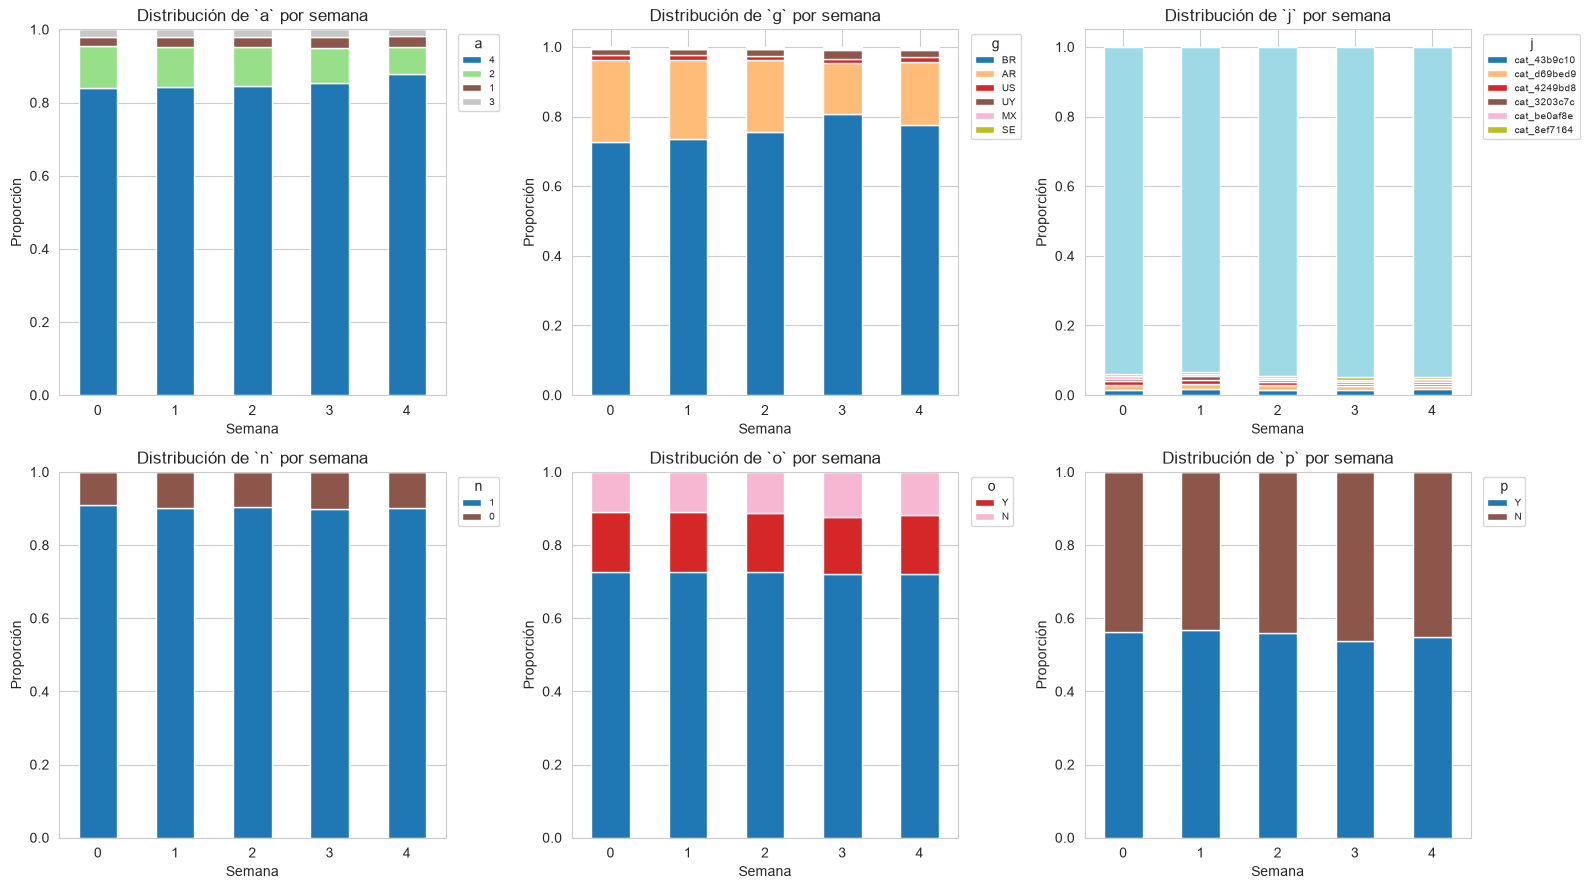

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_FEATURES):
    filled_ref = reference_df[col].astype(object).where(reference_df[col].notna(), "__MISSING__")
    top_categories = filled_ref.value_counts().head(6).index

    prop_by_week = pd.DataFrame({
        week: category_proportions(df.loc[df["semana"] == week, col], top_categories)
        for week in sorted(df["semana"].unique())
    }).T

    prop_by_week.plot(kind="bar", stacked=True, ax=axes[i], colormap="tab20", legend=False)
    axes[i].set_title(f"Distribución de `{col}` por semana")
    axes[i].set_xlabel("Semana"); axes[i].set_ylabel("Proporción")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, title=col)

fig.tight_layout()
plt.show()


## 4. Nulos: ¿cambia la tasa de nulos semana a semana?

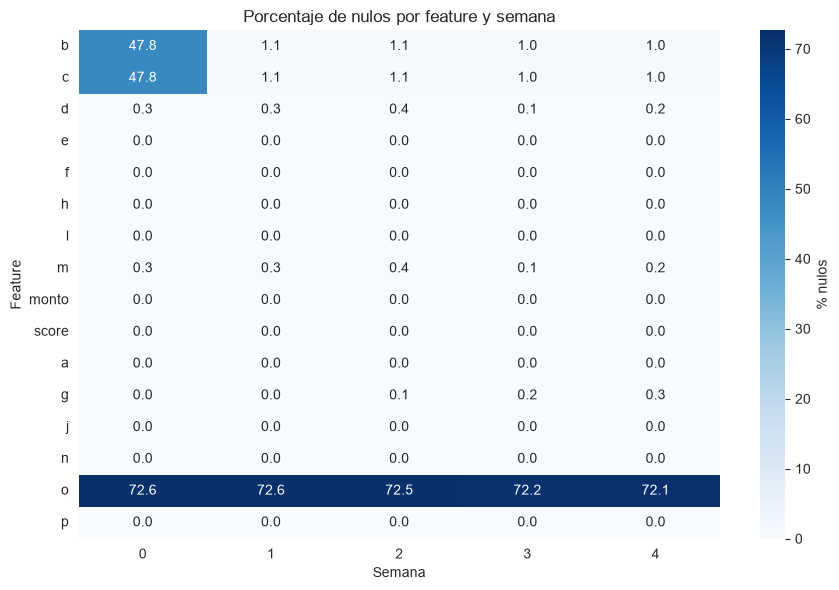

In [12]:
all_features = CONTINUOUS_FEATURES + CATEGORICAL_FEATURES
null_rate = (df.groupby("semana")[all_features].apply(lambda g: g.isna().mean()) * 100).T

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(null_rate, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% nulos"}, ax=ax)
ax.set_title("Porcentaje de nulos por feature y semana")
ax.set_xlabel("Semana"); ax.set_ylabel("Feature")
fig.tight_layout()
plt.show()


**Hallazgo relevante**: 
- `b` y `c` (que siempre tienen nulos en las mismas filas) muestran **47.8% de nulos en la semana 0**, y caen a ~1% desde la semana 1 en adelante. Mirando día a día *dentro* de la semana 0, el patrón es errático (0.8% → 62% → 42% → 40% → 100% → 62% → 1.3%), no una caída gradual, esto es más compatible con una **inestabilidad de un sistema/feed de datos durante el arranque del periodo capturado** que con un drift natural de la variable. Es exactamente el tipo de escenario descrito en "Consideraciones adicionales" (features que dejan de llegar / cambios de disponibilidad en el feed), y el motivo por el que monitorear la tasa de nulos por separado del KS es necesario: el KS de `b`/`c` (sección 2) se calcula solo sobre los valores no nulos, así que no refleja este cambio en absoluto.

## 5. Tabla resumen de drift

In [13]:
summary_rows = []

for col in CONTINUOUS_FEATURES:
    row = ks_pivot.loc[col]
    max_week = row.idxmax()
    max_val = row.max()
    summary_rows.append({
        "feature": col, "tipo": "continua", "metrica": "KS",
        "valor_max": round(float(max_val), 4), "semana_max": int(max_week),
        "valor_promedio": round(float(row.mean()), 4),
        "alerta": ks_drift_label(max_val),
    })

for col in CATEGORICAL_FEATURES:
    row = psi_pivot.loc[col]
    max_week = row.idxmax()
    max_val = row.max()
    summary_rows.append({
        "feature": col, "tipo": "categórica", "metrica": "PSI",
        "valor_max": round(float(max_val), 4), "semana_max": int(max_week),
        "valor_promedio": round(float(row.mean()), 4),
        "alerta": psi_label(max_val),
    })

severity_order = {"sin drift": 0, "drift leve": 1, "drift moderado": 1, "drift significativo": 2}
summary_df = pd.DataFrame(summary_rows)
summary_df["orden_alerta"] = summary_df["alerta"].map(severity_order)
summary_df = (
    summary_df.sort_values(["orden_alerta", "valor_max"], ascending=[False, False])
    .drop(columns="orden_alerta")
    .reset_index(drop=True)
)


def _highlight_alert(val):
    color = {
        "sin drift": "#c8e6c9",
        "drift leve": "#fff9c4",
        "drift moderado": "#fff9c4",
        "drift significativo": "#ffcdd2",
    }.get(val, "white")
    return f"background-color: {color}"


summary_df.style.map(_highlight_alert, subset=["alerta"])


,feature,tipo,metrica,valor_max,semana_max,valor_promedio,alerta
0,h,continua,KS,0.110900,3,0.081600,drift leve
1,b,continua,KS,0.104400,3,0.065500,drift leve
2,monto,continua,KS,0.103800,3,0.070100,drift leve
3,score,continua,KS,0.097800,4,0.048100,sin drift
4,e,continua,KS,0.069700,4,0.037400,sin drift
5,g,categórica,PSI,0.061200,3,0.023800,sin drift
6,c,continua,KS,0.039100,4,0.020000,sin drift
7,d,continua,KS,0.031700,4,0.022800,sin drift
8,f,continua,KS,0.029000,3,0.017300,sin drift
9,j,categórica,PSI,0.028600,3,0.015500,sin drift


## Conclusiones

- **El hallazgo más relevante no lo capta el KS, sino la tasa de nulos**: `b` y `c` tienen 47.8% de nulos en la semana 0 y caen a ~1% desde la semana 1 en adelante, con un patrón errático día a día dentro de la semana 0. Es compatible con una inestabilidad puntual del feed de datos al inicio del periodo capturado, no con un drift natural y es indetectable por el KS, porque este se calcula solo sobre los valores no nulos. Esto confirma por qué monitorear nulos por separado (no solo la distribución de los valores presentes) es necesario en producción.
- **Ninguna feature alcanza "drift significativo"** (KS > 0.20 o PSI > 0.25) en la distribución de sus valores no nulos, en ninguna semana frente a la semana de referencia.
- **3 variables continuas muestran "drift leve"** hacia las semanas 3-4: `b` (KS máx. 0.104), `h` (KS máx. 0.111) y `monto` (KS máx. 0.104), con un crecimiento progresivo (no un salto abrupto), consistente con un corrimiento gradual de la distribución.
- **`score` está justo debajo del umbral** (KS máx. 0.098 en semana 4), vale la pena vigilarlo junto con `b`/`h`/`monto`, dado que `score` y `monto` están entre las features con mayor peso en varios de los modelos evaluados en `03_model_selection`.
- **Las variables categóricas son muy estables**: el PSI máximo observado es 0.061 (`g`, semana 3), muy por debajo del umbral de 0.10, no hay evidencia de cambios en la composición de categorías (tampoco en `o`, la variable con más nulos y mayor asociación con el target).
- El drift leve de `b`/`h`/`monto` coincide temporalmente con el aumento de la tasa de fraude semanal (4.84% → 4.52% → 5.46% → 5.95% → 5.56%), lo que sugiere que ese corrimiento podría estar asociado al cambio en la mezcla de fraude/no-fraude del periodo, más que a un problema de calidad de datos.

**Recomendación**: con esta magnitud de drift en los valores no nulos no se justifica un reentrenamiento inmediato, pero sí conviene: (1) investigar la causa raíz de la inestabilidad de nulos de `b`/`c` en la semana 0 antes de asumir que el feed está sano hoy, y (2) incorporar `b`, `h`, `monto` y `score` como las primeras features a vigilar en un dashboard de monitoreo productivo (ver slide "Consideraciones adicionales" del resumen del proyecto), recalculando este mismo KS/PSI/tasa de nulos semana a semana contra la ventana de entrenamiento una vez el modelo esté en producción.
